# Success Rate measure for a power analysis attack on AES with custom SBox

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import serial.tools.list_ports as port_list
import sys
sys.path.append( '../AES_python' )
sys.path.append( '../sca_python' )
sys.path.append( '../x-heep' )

import readFirmware

ports = list(port_list.comports())
for p in ports:
    print (p)

# An already generated bitstream is available in the repository at the path:
bitstream = r"../../hw/fpga/bitstream/xheep/cw305_top.bit"
# Alternatively, you can generate the bitstream yourself by running the following command:
#   make vivado-fpga
# and the generated bitstream will be available at the path:
#bitstream = r"../../hw/vendor/cw305-heep/build/polito_cw305_heep_cw305_heep_0.0.1/cw305-vivado/polito_cw305_heep_cw305_heep_0.0.1.runs/impl_1/cw305_top.bit"
# Note that this folder is temporary and will be deleted when you run the 'make clean' command.

verilog_defines = r"../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v"

"""
Available S-boxes:
    sbox_rijandael (default AES S-Box) (aes_sbox)
    sbox_freyre_1
    sbox_freyre_2
    sbox_freyre_3
    sbox_hussain_6
    sbox_ozkaynak_1
    sbox_azam_1
    sbox_azam_2
    sbox_azam_3
"""
tested_sbox = "sbox_rijandael"
sbox_id = tested_sbox.replace("sbox_", "")

# TODO: add precompiled firmware also for the masked AES. Now it is not available.
masked_flag = False

# The firmware is already compiled and available in the repository for all S-boxes.

#TODO: remove the project file and use just the traces
if masked_flag:
  firmware = r"../x-heep/AES_masked_firmware_random_plaintext/main_"+sbox_id+".hex"
  project_file = "../../build/xheep_test/xheep_test_CW305_SR_"+sbox_id+"_masked.cwp"
else:
  firmware = r"../x-heep/AES_Sbox_firmware_random_plaintext/main_"+sbox_id+".hex"
  project_file = "../../build/xheep_test/xheep_test_CW305_SR_"+sbox_id+".cwp"

# To run a generic firmware compiled with the X-HEEP toolchain and structure,
# you can use the following path:
# firmware = r"../../hw/vendor/cw305-heep/sw/build/main.hex"

/dev/ttyS4 - n/a
/dev/ttyS31 - n/a
/dev/ttyS30 - n/a
/dev/ttyS29 - n/a
/dev/ttyS28 - n/a
/dev/ttyS27 - n/a
/dev/ttyS26 - n/a
/dev/ttyS25 - n/a
/dev/ttyS24 - n/a
/dev/ttyS23 - n/a
/dev/ttyS22 - n/a
/dev/ttyS21 - n/a
/dev/ttyS20 - n/a
/dev/ttyS19 - n/a
/dev/ttyS18 - n/a
/dev/ttyS17 - n/a
/dev/ttyS16 - n/a
/dev/ttyS15 - n/a
/dev/ttyS14 - n/a
/dev/ttyS13 - n/a
/dev/ttyS12 - n/a
/dev/ttyS11 - n/a
/dev/ttyS10 - n/a
/dev/ttyS9 - n/a
/dev/ttyS8 - n/a
/dev/ttyS7 - n/a
/dev/ttyS6 - n/a
/dev/ttyS5 - n/a
/dev/ttyS3 - n/a
/dev/ttyS2 - n/a
/dev/ttyS1 - n/a
/dev/ttyS0 - n/a
/dev/ttyUSB3 - Quad RS232-HS - Quad RS232-HS
/dev/ttyUSB2 - Quad RS232-HS - Quad RS232-HS
/dev/ttyUSB1 - Quad RS232-HS - Quad RS232-HS
/dev/ttyUSB4 - FT232R USB UART - FT232R USB UART


In [3]:
print("bitstream: ", bitstream)
print("firmware: ", firmware)
print("verilog_defines: ", verilog_defines)
print("project_file: ", project_file)

bitstream:  ../../hw/fpga/bitstream/xheep/cw305_top.bit
firmware:  ../x-heep/AES_Sbox_firmware_random_plaintext/main_rijandael.hex
verilog_defines:  ../../hw/vendor/cw305-heep/hw/fpga/cw305_aes_defines.v
project_file:  ../../build/xheep_test/xheep_test_CW305_SR_rijandael.cwp


In [4]:
from picoscope import ps5000a
import chipwhisperer as cw
import time
from picosdk.discover import find_all_units

import os
os.system("pip list | grep chipwhisperer")



chipwhisperer                     5.7.0


You should consider upgrading via the '/home/lorenzo_capobianco/.pyenv/versions/3.9.5/bin/python3.9 -m pip install --upgrade pip' command.


0

## Picoscope and CW305 initialization

In [5]:
from pico_api import PS5000aWrapper

try:
    # Initialize picoscope
    ps = PS5000aWrapper()
    ps.get_unitInfo()
    #ps.scope_setup(obs_time=1E-3, nSamples=400000) # 1ms time window, 400k samples which results in 2 ns sampling interval. Much higher than the 10 MHz clock frequency for X-HEEP.
    ps.scope_setup(obs_time=1E-4, nSamples=4000) # 0.1ms time window, 4k samples which results in ~25 ns sampling interval.


    # Initialize CW305 with required parameters. More in detail:
    # ps: picoscope object
    # cw.targets.CW305: target device
    # bsfile: bitstream file
    # force: force programming
    # slurp: used to get the device verilog defines for the register addresses
    # defines_files: verilog defines file path.
    cw305 = cw.target(None, cw.targets.CW305, bsfile=bitstream, force=True, slurp=True, defines_files=[verilog_defines])
    cw305.vccint_set(1.0)
    cw305.pll.pll_enable_set(True)             # enable PLL chip
    cw305.pll.pll_outenable_set(False, 0)      # disable PLL 0
    cw305.pll.pll_outenable_set(True, 1)       # enable PLL 1
    cw305.pll.pll_outenable_set(False, 2)      # disable PLL 2
    cw305.pll.pll_outfreq_set(10E6, 1)         # PLL1 frequency set to 10 MHz
    # Disable usb_clock. Optional, but reduces power trace noise
    cw305.clkusbautooff = True
    # 1 ms is plenty idling time 
    cw305.clksleeptime = 1

    # Set the clock source writing the corresponding register
    cw305.fpga_write(cw305.REG_CLKSETTINGS, data=bytearray([0x01]))
    # DEBUG
    # print("FPGA CLKSETTINGS REGISTER: ", cw305.fpga_read(cw305.REG_CLKSETTINGS, 1)[::-1])

    # Load firmware
    readFirmware.readFirmware(cw305, firmware)
    
except ModuleNotFoundError as e:
    print(e)

Found the following picoscope:
DriverVersion                 : PS5000A Linux Driver, 2.2.7.5057
USBVersion                    : 3.0
HardwareVersion               : 1
VariantInfo                   : 5244D
BatchAndSerial                : KU687/0175
CalDate                       : 26Apr23
KernelVersion                 : 0.0
DigitalHardwareVersion        : 1
AnalogueHardwareVersion       : 1
PicoFirmwareVersion1          : 1.7.15.0
PicoFirmwareVersion2          : 1.2.36.0

Firmware file '../x-heep/AES_Sbox_firmware_random_plaintext/main_rijandael.hex' found. Loading firmware...


...Firmware loaded. Setting boot exit loop flag...


...Done



In [6]:
print(ps.get_scopeSettings())
print()
print("Sampling Interval: ", ps.get_samplingInterval(), "s")

Nsamples :  4167
Sampling interval = %f us 2.4e-08
Channel A settings:  Channel A: Range = 50mV, AC coupling, 20 MHz BW limit
Channel B settings:  Channel B: Range = 10V, DC coupling, trigger
None

Sampling Interval:  2.4e-08 s


In [ ]:
# DEBUG
# cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))
# time.sleep(1E-3) # 1 ms
# cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

In [ ]:
# DEBUG
# cw305.dis()
# ps.dis()

## Online phase : AES power traces capture

In [7]:
from tqdm.notebook import tnrange
#import chipwhisperer as cw
from chipwhisperer.common.traces import Trace
from Crypto.Cipher import AES
from AES_golden import AES_golden_model

# Number of iterations
max_iterations = 1
# Number of traces to capture
N = 5000

# Initialize key and plain text.
key  = [ 0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c ]
text = [ 0x6e, 0xc1, 0x53, 0x9c, 0xfb, 0xe7, 0xf6, 0x18, 0x92, 0xac, 0x19, 0x87, 0xf5, 0x94, 0xe1, 0x2b ]

# Each element of the key is converted to a 2-digit hex string 
formatted_key = ''.join(format(el, '02x') for el in key)
print("Key: ", [ hex(subkey) for subkey in key])

# Initialize the AES software emulated cipher
cipher = AES_golden_model()

Key:  ['0x2b', '0x7e', '0x15', '0x16', '0x28', '0xae', '0xd2', '0xa6', '0xab', '0xf7', '0x15', '0x88', '0x9', '0xcf', '0x4f', '0x3c']


In [8]:
for iteration in range(1,max_iterations+1):
    print("Iteration: ", iteration)
    project_file = "../../build/xheep_test/xheep_CW305_AES_success_rate_" + sbox_id + "_iteration_" + str(iteration) + ".cwp"
    project = cw.create_project(project_file, overwrite=True)

    # TODO: solve this bug. Apparently the sbox_rijandael is called sbox_aes somewhere.
    if tested_sbox == "sbox_rijandael":
        tested_sbox = "sbox_aes"

    # Trigger the iteration start in the firmware
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))
    time.sleep(1E-3) # 1 ms
    cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

    for i in tnrange(N, desc='Capturing traces'):
        # Run the target
        ps.runBlock()
        time.sleep(0.05)

        # Write 8 to the status register to trigger the program execution and the scope acquisition
        cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x08]))

        ps.waitReady()

        # Get captured trace 
        data = ps.getDataV()

        trace = Trace(np.array(data), text, cipher.encrypt(formatted_key, text, tested_sbox), key)
        project.traces.append(trace)
        #print("Cipertext: ", [ hex(subkey) for subkey in cipher.encrypt(formatted_key, text, tested_sbox)])
        
        # Update the plain text as the previous chipertext
        text = cipher.encrypt(formatted_key, text, tested_sbox)

        time.sleep(1E-3) # 1 ms
        # Reset the status register to reload the program execution and the scope acquisition
        cw305.fpga_write(cw305.REG_BRIDGE_STATUS, data=bytearray([0x00]))

    project.save()
    project.close()

# Disconnect CW305 and picoscope
cw305.dis()
ps.dis()

Iteration:  1


Capturing traces:   0%|          | 0/5000 [00:00<?, ?it/s]

## Offline Phase

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
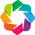

In [9]:
# Importing the required libraries for analysis
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
import holoviews as hv
hv.extension('bokeh')
from analyzer.attack.aes.SBox_leakage_models import AES128SboxResistantLeakageModels

# TODO: fix this bug.
if tested_sbox == "sbox_aes":
    tested_sbox = "sbox_rijandael"


### Success Rate

In [ ]:
from chipwhisperer.common.traces import Trace
from IPython.display import clear_output
import pandas as pd
from AES import AES as AESpy

# Functions to display the results in a Jupyter Notebook
def format_stat(stat):
    return str("{:02X}<br>{:.3f}".format(stat[0], stat[2]))

def color_corr_key(row):
    global key
    ret = [""] * 16
    for i,bnum in enumerate(row):
        if bnum[0] == key[i]:
            ret[i] = "color: red"
        else:
            ret[i] = ""
    return ret
    
# This function is used to check if the recovered key matches the initial key.
# To speed up the attack, if the recovered key matches the initial key for 10 
# consecutive iterations, the attack stops, since the result will be the same
# even analyzing more and more traces.
def check_success(bestguess):
    global successCount
    recv_key = AESpy.get_initial_key(bestguess, 0, sbox_id)
    if initial_key == recv_key:
        successCount +=1
        if successCount >= 10:
            return 1
        else:
            return 0
    else:
        successCount = 0
        return 0
    
class StopExecutionException(Exception):
    pass

# This function is used to display the statistics of the attack
def stats_callback():
    global current_trace_iteration
    global result_success
    global partialGuessingEntropy
    
    results = attack.results
    results.set_known_key(key)
    
    # Success rate calculation
    bestguess = [kguess[0][0] for kguess in results.find_maximums()]
    results_success[current_trace_iteration] = check_success(bestguess)
    if results_success[current_trace_iteration] == 1:
        raise StopExecutionException("Reached Limit")
    
    stat_data = results.find_maximums()
    df = pd.DataFrame(stat_data).transpose()
    clear_output(wait=True)
    tstart = current_trace_iteration * resolution
    tend = tstart + resolution
    current_trace_iteration += 1
    display(df.head().style.format(format_stat).apply(color_corr_key,axis=1).set_caption("Iteration {}. Trial {}. Finished traces {} to {}. Success {}".format(iteration, trial, tstart, tend, successCount)))

In [ ]:
# def check_success(bestguess):
#     """Return 1 if attack recovered the full key, else 0."""
#     recv_key = AESpy.get_initial_key(bestguess, 0, sbox_id)
#     return int(recv_key == initial_key)

# def stats_callback():
#     global current_trace_iteration, results_success
    
#     results = attack.results
#     results.set_known_key(key)                     # optional – only for display/GE

#     # -- SUCCESS RATE UPDATE -----------------------------------------------
#     bestguess   = [kg[0][0] for kg in results.find_maximums()]
#     success_bit = check_success(bestguess)         # 1 or 0
#     results_success[current_trace_iteration] = success_bit
#     current_trace_iteration += 1
#     # ----------------------------------------------------------------------

#     # pretty-printing (unchanged)
#     stat_data = results.find_maximums()
#     df = (pd.DataFrame(stat_data).transpose()
#             .style.format(format_stat)
#             .apply(color_corr_key, axis=1)
#             .set_caption(f"Iteration {iteration} · Trial {trial} · "
#                           f"Traces used {(current_trace_iteration-1)*resolution}–"
#                           f"{current_trace_iteration*resolution-1}"))
#     clear_output(wait=True)
#     display(df)


In [15]:
global current_trace_iteration
global result_success
global successCount

resolution = 25
max_n_traces = 5000
n_trials = 1
max_n_iteration = 1

for iteration in range(1,max_n_iteration+1):

    project_file = "../../build/xheep_test/xheep_CW305_AES_success_rate_" + sbox_id + "_iteration_" + str(iteration) + ".cwp"
    project = cw.open_project(project_file)

    traces = project.waves[:]
    textin = project.textins[:]
    keys = project.keys[:]
    ciphertext = project.textouts[:]

    # DEBUG
    print("Number of traces: ", len(traces))

    for trial in range(0,n_trials):

        success_file = "../../build/xheep_test/xheep_CW305_AES_success_rate_.cwp"
        success_project = cw.create_project(success_file, overwrite=True)

        for n_trace in range(max_n_traces):
            traces_trial = traces[trial*max_n_traces+n_trace]
            textin_trial = textin[trial*max_n_traces+n_trace]
            ciphertext_trial = ciphertext[trial*max_n_traces+n_trace]
            keys_trial = keys[trial*max_n_traces+n_trace]
            trace_i = Trace(traces_trial, textin_trial, ciphertext_trial, keys_trial)
            success_project.traces.append(trace_i)

        # DEBUG
        print(f"Trial {trial}: using traces {trial*max_n_traces} to {(trial+1)*max_n_traces-1}")

        success_project.save()

        print(len(success_project.traces[:]))

        successCount = 0
        current_trace_iteration = 0
        results_success = [1] * int(200)

        initial_key = list(success_project.keys[0])

        inpkey = success_project.keys[0]
        input_key = ""
        for subkey in inpkey:
            input_key = input_key + format(subkey, "02x")
        # round_10_key = AESpy.get_round_key(input_key, 10, sbox_type)

        leak_model = AES128SboxResistantLeakageModels().FirstRound_ModifiedSbox_Output(tested_sbox)
        attack = cwa.cpa(success_project, leak_model)
        try:
            results = attack.run(stats_callback, resolution)
        except StopExecutionException as e:
            print(f"Execution stopped: {e}")

        success_project.close()

        # Success Rate saving
        
        success_file_name = "../x-heep/results/AES_cpa_success_rate_" + sbox_id + "_success_results_trial_" + str(trial+10*(iteration-1)) + ".txt"
        with open(success_file_name,'w') as success_file:
            for success in results_success:
                print(success, file=success_file)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2B0.296,7E0.282,150.322,160.273,280.360,AE0.377,D20.297,A60.254,AB0.384,F70.363,150.357,880.291,090.412,CF0.348,4F0.393,3C0.400
1,EA0.194,C50.207,770.190,980.202,DE0.222,DC0.215,970.224,EB0.200,040.209,410.207,250.216,960.206,360.229,A60.206,F20.216,380.199
2,850.189,8A0.194,780.183,F90.196,FC0.214,9A0.192,9E0.205,610.198,6E0.204,E00.206,490.206,D70.195,800.213,F00.203,760.193,2D0.193
3,930.184,410.189,240.182,560.188,900.212,EB0.187,FF0.197,FF0.184,EB0.203,320.196,A40.203,640.187,900.193,170.192,DD0.192,DA0.191
4,ED0.179,5D0.181,140.182,BC0.181,5D0.198,9D0.186,B40.193,1B0.184,890.191,980.196,4F0.203,850.183,620.191,C60.188,480.190,0C0.189


Execution stopped: Reached Limit


In [16]:
success_rate = [0] * int(max_n_traces/resolution)

# n_trials = 100

def mean(X):
    return np.sum(X, axis=0)/len(X)

trials_success_results_temp = []
for i in range(n_trials):
    success_file_name = "../x-heep/results/AES_cpa_success_rate_" + sbox_id + "_success_results_trial_" + str(i) + ".txt"
    with open(success_file_name, 'r') as file_read:
        data = [int(line.strip()) for line in file_read]
        trials_success_results_temp.append(data)

trials_success_results = list(zip(*trials_success_results_temp))

for i in range(int(max_n_traces/resolution)):
    success_rate[i] = mean(trials_success_results[i])

In [ ]:
# Interactive plot

from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import CrosshairTool

output_notebook()
p = figure(plot_width=800)

xrange = range(len(success_rate))
p.line(xrange, success_rate, line_color="red")
show(p)

Loading BokehJS ...

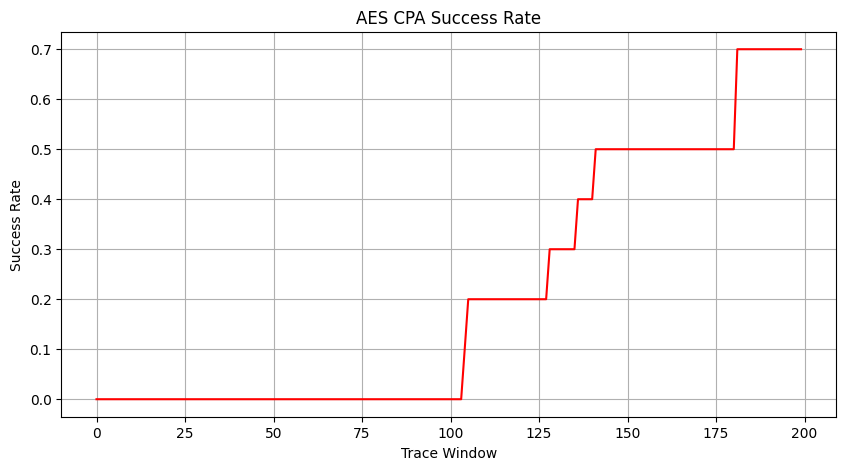

In [ ]:
# Normal plot with matplotlib

import matplotlib.pyplot as plt

xrange = range(len(success_rate))
plt.figure(figsize=(10, 5))
plt.plot(xrange, success_rate, color="red")
plt.xlabel("Trace Window")
plt.ylabel("Success Rate")
plt.title("AES CPA Success Rate")
plt.grid(True)
#plt.savefig("../x-heep/Graphs/AES_c/AES_cpa_success_rate_" + sbox_id + ".png", dpi=300)
plt.show()